<a href="https://colab.research.google.com/github/elinsyn/Fluid_mechanics/blob/main/Barcelona.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# About the code

In [112]:
# Copyright (C) 2019 Johan Hoffman (jhoffman@kth.se)

# Setup environment

In [113]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# Define domain and mesh

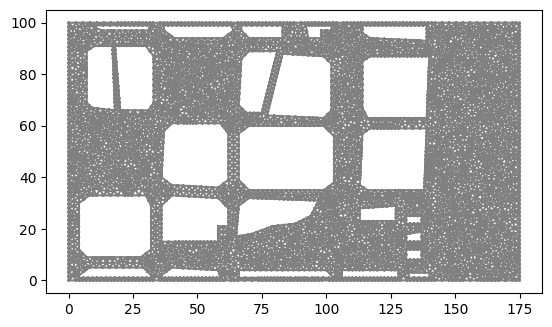

In [114]:
# Define domain
L = 175
H = 100

# Define subdomains
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

left = Left()
right = Right()
lower = Lower()
upper = Upper()

resolution = 64

# Generate mesh
domain = Rectangle(Point(0.0,0.0), Point(L,H))

# Barcelona
casa1 = Polygon([Point(139, 99), Point(114, 99), Point(114, 96), Point(117, 94), Point(139, 93)])
casa2 = Polygon([Point(102, 99), Point(92, 99), Point(93, 94), Point(98, 94), Point(98, 97), Point(102, 97)])
casa3 = Polygon([Point(83, 99), Point(67, 99), Point(67, 97), Point(70, 94), Point(83, 94)])
casa4 = Polygon([Point(63, 99), Point(37, 99), Point(37, 97), Point(41, 94), Point(60, 94), Point(64, 97)])
casa5 = Polygon([Point(32, 99), Point(8, 99), Point(8, 99), Point(13, 97), Point(31, 97)])
casa6 = Polygon([Point(140, 87), Point(117, 87), Point(114, 85), Point(114, 67), Point(116, 63), Point(139, 63)])
casa7 = Polygon([Point(99, 87), Point(83, 88), Point(77, 64), Point(99, 63), Point(102, 66), Point(102, 84)])
casa8 = Polygon([Point(81, 89), Point(70, 89), Point(67, 86), Point(66, 68), Point(69, 65), Point(75, 65)])
casa9 = Polygon([Point(30, 91), Point(18, 91), Point(20, 66), Point(31, 66), Point(33, 69), Point(33, 87)])
casa10 = Polygon([Point(17, 91), Point(10, 91), Point(7, 89), Point(7, 69), Point(9, 67), Point(18, 66)])
casa11 = Polygon([Point(139, 59), Point(117, 59), Point(114, 57), Point(113, 37), Point(116, 35), Point(138, 35)])
casa12 = Polygon([Point(99, 60), Point(70, 60), Point(66, 57), Point(66, 39), Point(70, 35), Point(99, 35), Point(103, 38), Point(103, 56)])
casa13 = Polygon([Point(59, 61), Point(40, 61), Point(37, 58), Point(36, 40), Point(40, 37), Point(58, 36), Point(62, 39), Point(62, 57)])
casa14 = Polygon([Point(137, 25), Point(131, 25), Point(131, 22), Point(137, 22)])
casa15 = Polygon([Point(137, 19), Point(131, 18), Point(131, 15), Point(137, 15)])
casa16 = Polygon([Point(137, 12), Point(131, 12), Point(131, 8), Point(137, 8)])
casa17 = Polygon([Point(127, 29), Point(113, 28), Point(113, 23), Point(127, 23)])
casa18 = Polygon([Point(97, 31), Point(70, 32), Point(66, 29), Point(65, 17), Point(71, 18), Point(79, 21), Point(88, 22), Point(94, 25)])
casa19 = Polygon([Point(58, 32), Point(40, 33), Point(36, 29), Point(36, 15), Point(58, 15), Point(58, 21), Point(62, 21), Point(62, 28)])
casa20 = Polygon([Point(30, 33), Point(8, 33), Point(4, 30), Point(4, 12), Point(7, 9), Point(28, 9), Point(32, 12), Point(32, 29)])
casa21 = Polygon([Point(140, 3), Point(132, 3), Point(132, 1), Point(140, 1)])
casa22 = Polygon([Point(128, 4), Point(106, 4), Point(106, 1), Point(128, 1)])
casa23 = Polygon([Point(100, 4), Point(66, 4), Point(66, 1), Point(103, 1)])
casa24 = Polygon([Point(58, 4), Point(40, 5), Point(36, 2), Point(36, 1), Point(59, 1)])
casa25 = Polygon([Point(29, 5), Point(8, 5), Point(4, 2), Point(4, 1), Point(32, 1), Point(32, 2)])
casa = casa1 + casa2 + casa3 + casa4 + casa5 + casa6 + casa7 + casa8 + casa9 + casa10 + casa11 + casa12 + casa13 + casa14 + casa15 + casa16 + casa17 + casa18 + casa19 + casa20 + casa21 + casa22 + casa23 + casa24 + casa25

mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - casa, resolution)

# Refine mesh
no_levels = 0
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(0.5, 0.5)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

#plot(Q.mesh())

# Define mesh functions
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)

plot(mesh)

# Define approximation spaces

In [115]:
# Generate finite element spaces
#VE = VectorElement("CG", mesh.ufl_cell(), 1)
#QE = FiniteElement("CG", mesh.ufl_cell(), 1)
#WE = VE * QE

#W = FunctionSpace(mesh, WE)
#V = FunctionSpace(mesh, VE)
#Q = FunctionSpace(mesh, QE)

V = VectorFunctionSpace(mesh, "Lagrange", 1)
Q = FunctionSpace(mesh, "Lagrange", 1)
K = FunctionSpace(mesh, "Discontinuous Lagrange", 0)

# Define trial and test functions
#(u, p) = TrialFunctions(W)
#(v, q) = TestFunctions(W)
u = TrialFunction(V)
p = TrialFunction(Q)
v = TestFunction(V)
q = TestFunction(Q)

# Define boundary conditions

In [116]:
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return (
            on_boundary
            and near(x[1], 0.0)
            and not near(x[0], 0.0)
            and not near(x[0], L)
        )

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        return (
            on_boundary
            and near(x[1], H)
            and not near(x[0], 0.0)
            and not near(x[0], L)
        )

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L)

class BuildingBoundary(SubDomain):
    def inside(self, x, on_boundary):
        return (
            on_boundary
            and not near(x[0], 0.0)
            and not near(x[0], L)
            and not near(x[1], 0.0)
            and not near(x[1], H)
        )



dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()

dbc_obj = DirichletBoundaryObjects()

#dbc_obj_vert = ObjectVerticalWalls()
#dbc_obj_horz = ObjectHorizontalWalls()

uin = -1.0

# Inlet
bcu_in0 = DirichletBC(V.sub(0), uin, dbc_right)
bcu_in1 = DirichletBC(V.sub(1), 0.0, dbc_right)

# Upper wall: slip condition
bcu_upp = DirichletBC(V.sub(1), 0.0, dbc_upper)
bcu_upp1 = DirichletBC(V.sub(1), 0.0, dbc_upper)

# Lower wall: slip condition
bcu_low1 = DirichletBC(V.sub(1), 0.0, dbc_lower)

# Object slip condition
# Vertical house walls: normal direction is x-direction, so set u_x = 0
bcu_obj0 = DirichletBC(V.sub(0), 0.0, dbc_obj)

# Horizontal house walls: normal direction is y-direction, so set u_y = 0
bcu_obj1 = DirichletBC(V.sub(1), 0.0, dbc_obj)

buildings = BuildingBoundary()
buildings.mark(boundaries, 5)

# Pressure outlet
pout = 0.0
bcp1 = DirichletBC(Q, pout, dbc_left)

bcu = [bcu_in0, bcu_in1,
       bcu_upp1,
       bcu_low1,
       bcu_obj0,
       bcu_obj1]

bcp = [bcp1]

# Define model parameters

In [117]:
# Set permeability matrix
Kinv11 = Expression('100.0*fabs(sin(2.0*pi*(x[1] - 0.1*x[0])))', element = K.ufl_element())
Kinv12 = Expression('0.0', element = K.ufl_element())
Kinv21 = Kinv12
Kinv22 = Kinv11

# Set viscosity
nu = 1.0e-2

# Set effective viscosity
nueff = 1.0e-2

# Define method parameters

In [118]:
# Define functions
u0 = Function(V)
u1 = Function(V)
p0 = Function(Q)
p1 = Function(Q)

# Set method parameters
num_nnlin_iter = 5
prec = "amg" if has_krylov_solver_preconditioner("amg") else "default"

# Time step length
dt = 0.5*mesh.hmin()

# Define measure for boundary integration
ds = Measure('ds', domain=mesh, subdomain_data=boundaries)

# Define varitional problem

In [119]:
# Define variational problems
#d1 = 1.0*mesh.hmin()
#d2 = 1.0*mesh.hmin()
#d3 = 1.0e-2*mesh.hmin()

ds = Measure("ds", domain=mesh, subdomain_data=boundaries)
n = FacetNormal(mesh)
gamma_slip = Constant(100.0)

h = CellDiameter(mesh);
u_mag = sqrt(dot(u1,u1))
d1 = 1.0/sqrt((pow(1.0/dt,2.0) + pow(u_mag/h,2.0)))
#d1 = h
#d2 = 0.0
d2 = h*u_mag

um = 0.5*(u + u0)
um1 = 0.5*(u1 + u0)
Fu = inner((u - u0)/dt + grad(um)*um1, v)*dx - p1*div(v)*dx + nueff*inner(grad(um), grad(v))*dx \
    + d1*inner((u - u0)/dt + grad(um)*um1 + grad(p1), grad(v)*um1)*dx + d2*div(um)*div(v)*dx \
    + nu*(Kinv11*inner(um[0],v[0])*dx + Kinv12*inner(um[0],v[1])*dx + Kinv21*inner(um[1],v[0])*dx + Kinv22*inner(um[1],v[1])*dx)

au = lhs(Fu)
Lu = rhs(Fu)

Fp = d1*inner((u1 - u0)/dt + grad(um1)*um1 + grad(p), grad(q))*dx + div(um1)*q*dx
ap = lhs(Fp)
Lp = rhs(Fp)

# Assemble linear matrix
# Ap = assemble(ap)

# Set I/O variables

In [120]:
# Open files
file_u = File("results-BNS/u.pvd")
file_p = File("results-BNS/p.pvd")

# Set plot frequency
plot_time = 0
plot_freq = 10

# Time stepping algorithm

Time t = 0.6150755662233877


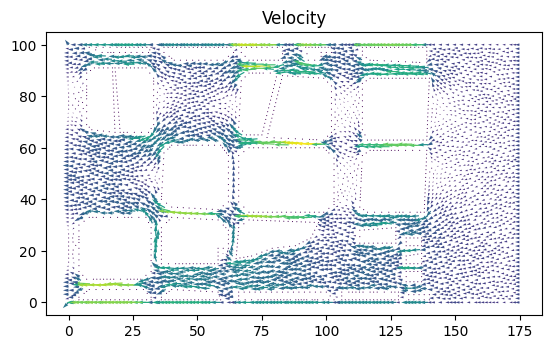

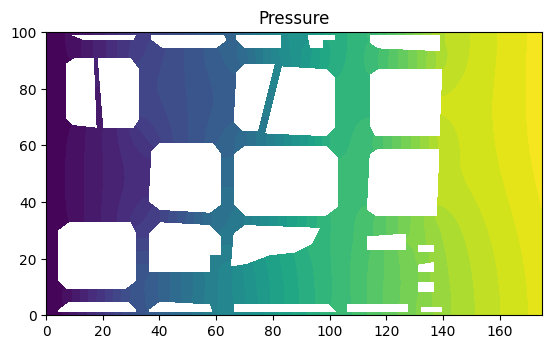

Time t = 1.2301511324467753


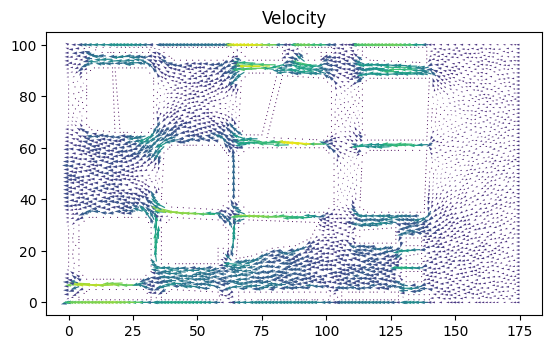

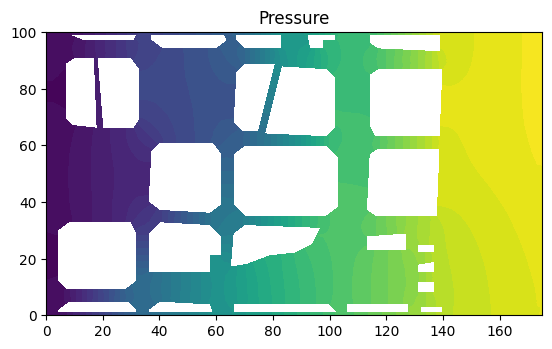

Time t = 2.4603022648935506


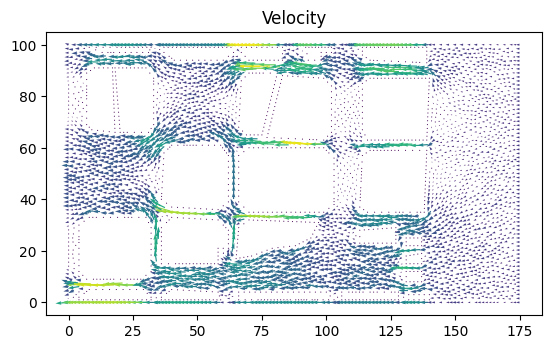

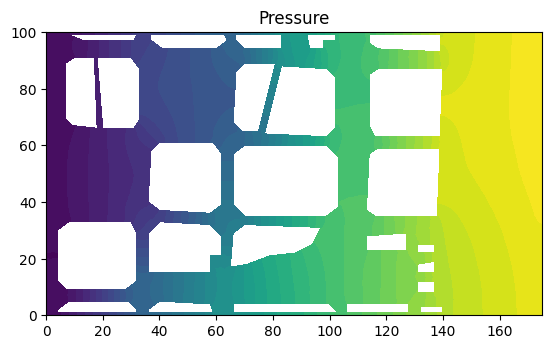

Time t = 3.0753778311169384


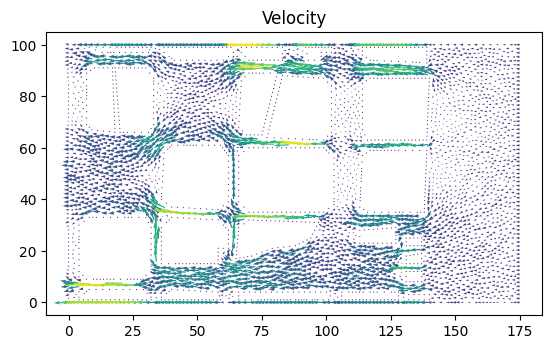

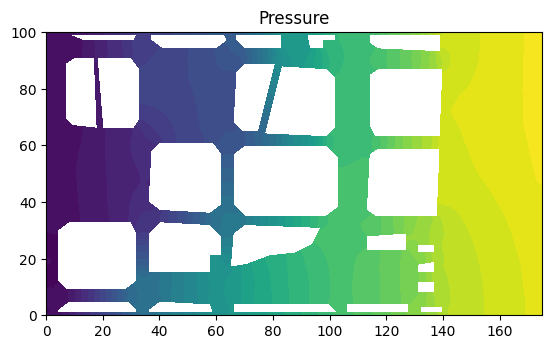

Time t = 4.305528963563714


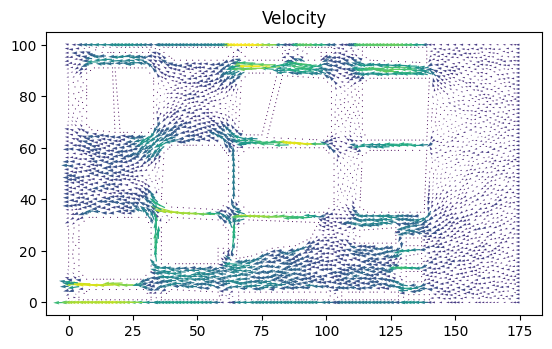

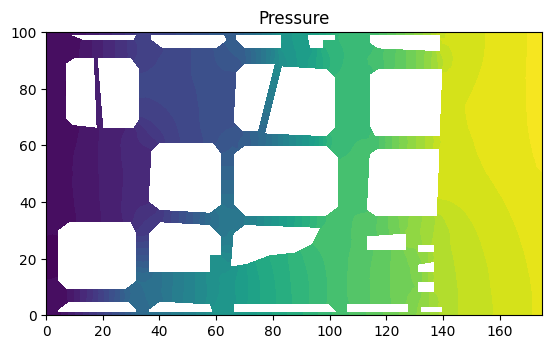

Time t = 5.535680096010489


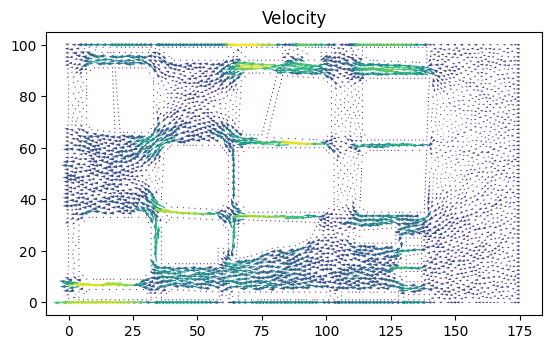

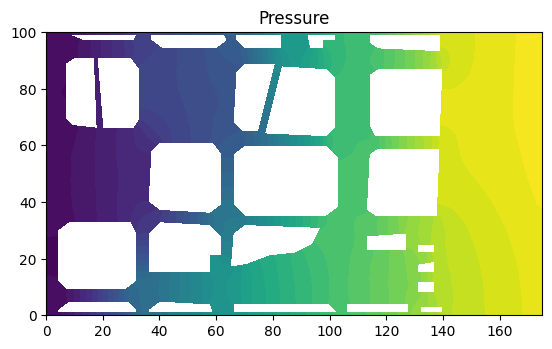

Time t = 6.150755662233876


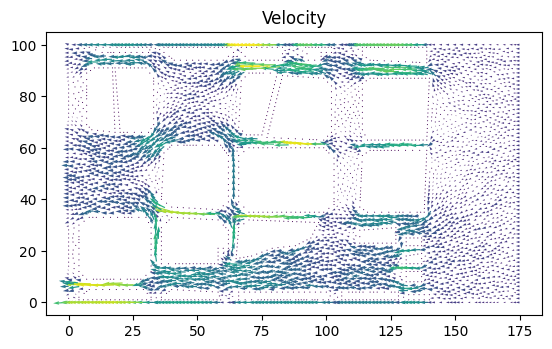

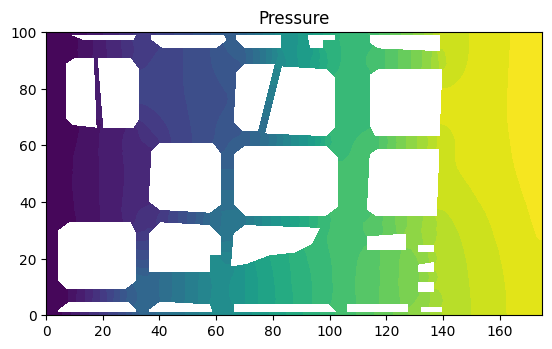

Time t = 7.380906794680651


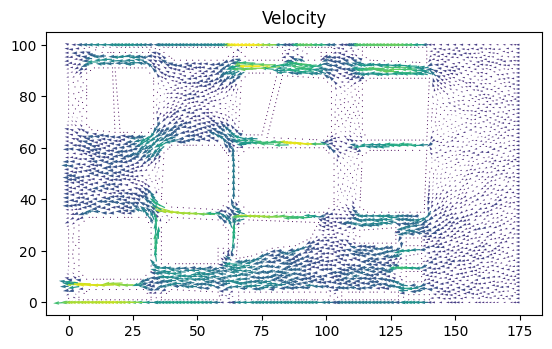

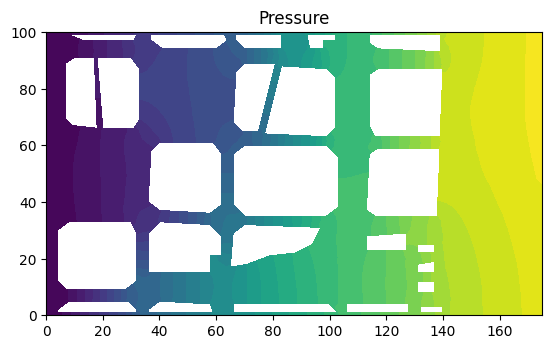

Time t = 8.611057927127426


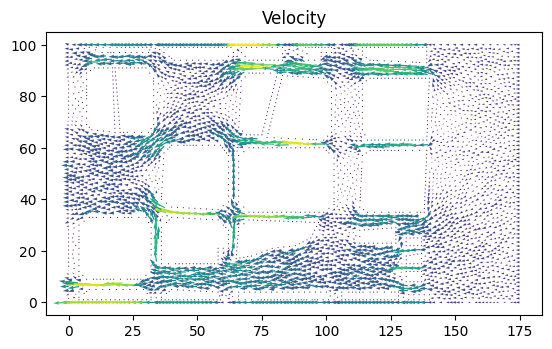

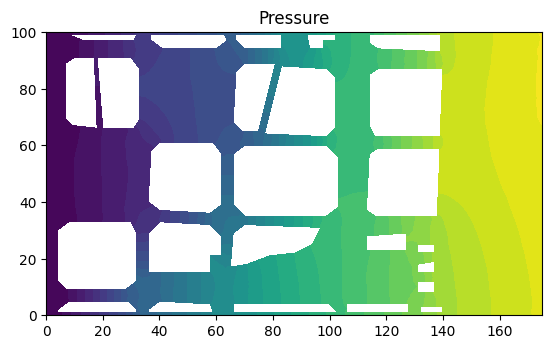

Time t = 9.226133493350813


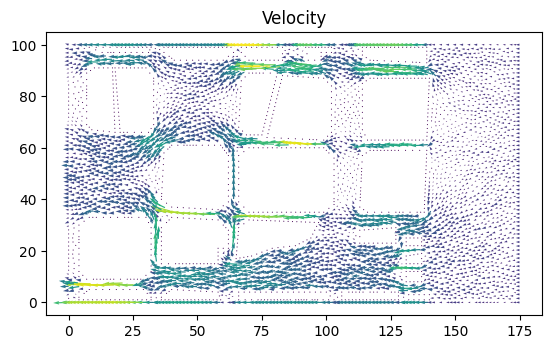

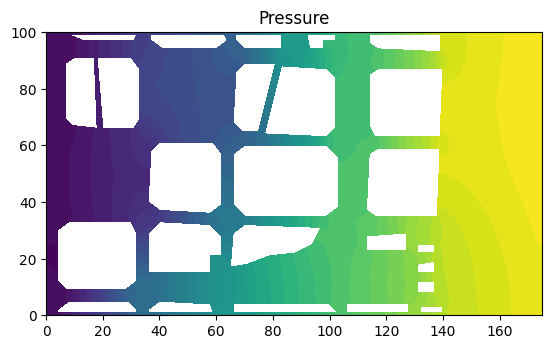

In [121]:
!rm results-BNS/*

# Time stepping
T = 10
t = dt
while t < T + DOLFIN_EPS:

    #s = 'Time t = ' + repr(t)
    #print(s)

    # Solve non-linear problem
    k = 0
    while k < num_nnlin_iter:

        # Assemble matrix and vector
        Au = assemble(au)
        bu = assemble(Lu)

        # Compute solution
        [bc.apply(Au, bu) for bc in bcu]
        [bc.apply(u1.vector()) for bc in bcu]
        solve(Au, u1.vector(), bu, "bicgstab", "default")

        # Assemble matrix and vector
        Ap = assemble(ap)
        bp = assemble(Lp)

        # Compute solution
        [bc.apply(Ap, bp) for bc in bcp]
        [bc.apply(p1.vector()) for bc in bcp]
        solve(Ap, p1.vector(), bp, "bicgstab", prec)

        k += 1

    if t > plot_time:

        s = 'Time t = ' + repr(t)
        print(s)

        # Save solution to file
        file_u << u1
        file_p << p1

        # Plot solution
        plt.figure()
        plot(u1, title="Velocity")

        plt.figure()
        plot(p1, title="Pressure")

        plot_time += T/plot_freq

        plt.show()

    # Update time step
    u0.assign(u1)
    t += dt

plt.show()

#!tar -czvf results-BNS.tar.gz results-BNS
#files.download('results-BNS.tar.gz')